In [329]:
# Make a connection between google colab to drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [330]:
# Basic Libraries
import os
import random
import warnings
warnings.filterwarnings('ignore')

In [331]:
#  to make a dataset inside the project folder

dataset_path = "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Dataset"

test_path=os.path.join(dataset_path,"test")
train_path=os.path.join(dataset_path,"train")
val_path=os.path.join(dataset_path,"val")

In [332]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical


from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download("punkt")










[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [333]:
# Load the dataset

dataset_path = "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Dataset"

# Load Training Data

train_df = pd.read_csv(os.path.join(dataset_path, "train.txt"),
                       sep=";",
                       names=["Text", "Emotion"])


# Load Validation Data
val_df = pd.read_csv(
    os.path.join(dataset_path, "val.txt"),
    sep=";",
    names=["Text", "Emotion"]
)

# Load Test Data
test_df = pd.read_csv(
    os.path.join(dataset_path, "test.txt"),
    sep=";",
    names=["Text", "Emotion"]
)


In [334]:
# Verify the data

print("Training Data Shape :", train_df.shape)
print("Validation Data Shape :", val_df.shape)
print("Testing Data Shape :", test_df.shape)

Training Data Shape : (16000, 2)
Validation Data Shape : (2000, 2)
Testing Data Shape : (2000, 2)


In [335]:
# Display the first few rows

train_df.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [336]:
# Check missing values

print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

Text       0
Emotion    0
dtype: int64
Text       0
Emotion    0
dtype: int64
Text       0
Emotion    0
dtype: int64


In [337]:
# Check class distribution

train_df["Emotion"].value_counts()


,count
Emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


# EDA

In [338]:
# Display Basic Information

print("Training Dataset Information")
train_df.info()

Training Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     16000 non-null  object
 1   Emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [339]:
# Dataset Statistics

train_df.describe(include='all')

,Text,Emotion
count,16000,16000
unique,15969,6
top,im still not sure why reilly feels the need to...,joy
freq,2,5362


In [340]:
# Check Duplicate Records

print("Duplicate Records:", train_df.duplicated().sum())

Duplicate Records: 1


In [341]:
# Remove Duplicates

train_df.drop_duplicates(inplace=True)
train_df.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [342]:
# Reset the index

train_df.drop_duplicates(inplace=True)
train_df.reset_index(drop=True, inplace=True)

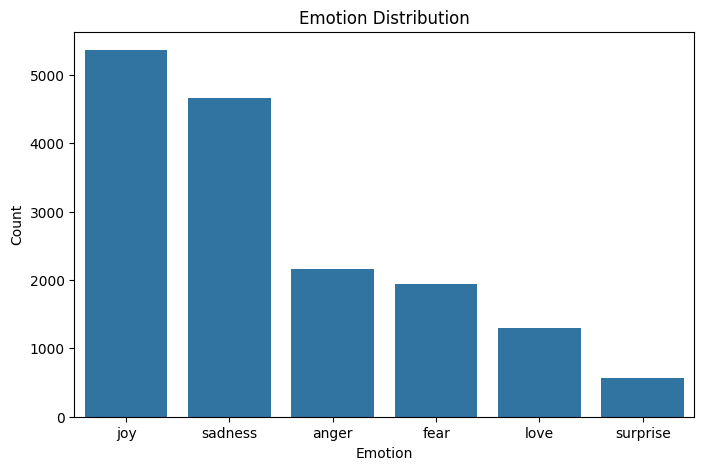

In [343]:
# Emotion Distribution Plot

plt.figure(figsize=(8,5))

sns.countplot(
    x=train_df['Emotion'],
    order=train_df['Emotion'].value_counts().index
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [344]:
# Sentence Length

train_df['Sentence_length'] = train_df['Text'].apply(len)

train_df.head()

,Text,Emotion,Sentence_length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20


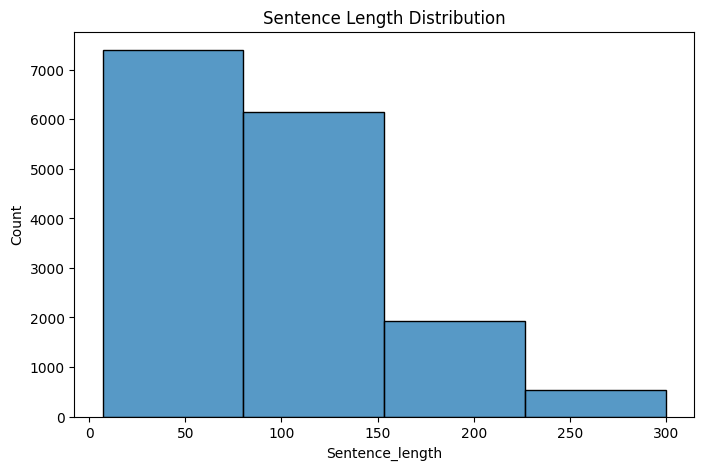

In [345]:
# Distribution of Sentence Length

plt.figure(figsize=(8,5))

sns.histplot(train_df["Sentence_length"], bins=4)
plt.title("Sentence Length Distribution")
plt.show()

In [346]:
# Word Count

train_df["Word_Count"] = train_df["Text"].apply(lambda x: len(x.split()))
train_df.head()

,Text,Emotion,Sentence_length,Word_Count
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,21
2,im grabbing a minute to post i feel greedy wrong,anger,48,10
3,i am ever feeling nostalgic about the fireplac...,love,92,18
4,i am feeling grouchy,anger,20,4


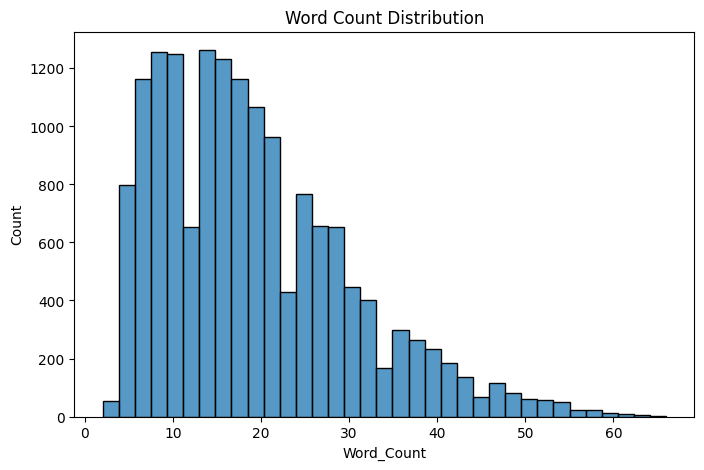

In [347]:
# Word Count Distribution

plt.figure(figsize=(8,5))
sns.histplot(train_df["Word_Count"], bins=35)
plt.title("Word Count Distribution")
plt.show()

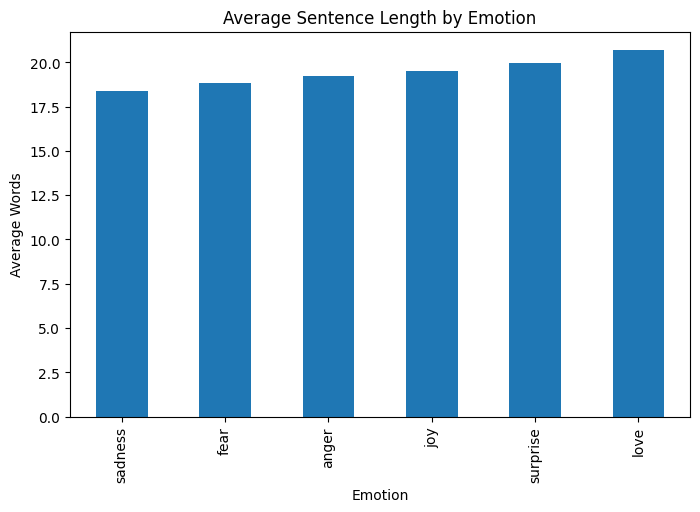

In [348]:
# Average Sentence Length per Emotion

emotion_length =train_df.groupby("Emotion")["Word_Count"].mean().sort_values()

plt.figure(figsize=(8,5))

emotion_length.plot(kind="bar")

plt.ylabel("Average Words")
plt.title("Average Sentence Length by Emotion")

plt.show()

# Data Cleaning & Text Preprocessing

In [349]:
# Initialize Objects

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [350]:
# Cleaning function for Deep Learning Models

def clean_text_dl(text):

    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = re.sub(r'\s+', ' ', text).strip()

    words=[]

    for word in text.split():

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            words.append(word)

    return " ".join(words)


In [351]:
# Claening function for Transformer Models

def clean_text_bert(text):

    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'http\S+|www\S+', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [352]:
# Apply cleaning

# Training Data

train_df["Clean_Text_DL"] = train_df["Text"].apply(clean_text_dl)

train_df["Clean_Text_BERT"] = train_df["Text"].apply(clean_text_bert)


In [353]:
# Validation Data

val_df["Clean_Text_DL"] = val_df["Text"].apply(clean_text_dl)

val_df["Clean_Text_BERT"] = val_df["Text"].apply(clean_text_bert)

In [354]:
# Test Data

test_df["Clean_Text_DL"] = test_df["Text"].apply(clean_text_dl)

test_df["Clean_Text_BERT"] = test_df["Text"].apply(clean_text_bert)

In [355]:
# Check Results

train_df[
    ["Text",
     "Clean_Text_DL",
     "Clean_Text_BERT"]
].head(10)

,Text,Clean_Text_DL,Clean_Text_BERT
0,i didnt feel humiliated,didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive taking milligram time recommended amount i...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,petronas year feel petronas performed well mad...,i have been with petronas for years i feel tha...
9,i feel romantic too,feel romantic,i feel romantic too


In [356]:
# Encode Labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_df["Label"] = encoder.fit_transform(train_df["Emotion"])

val_df["Label"] = encoder.transform(val_df["Emotion"])

test_df["Label"] = encoder.transform(test_df["Emotion"])

In [357]:
# Verify Label Mapping

label_mapping = dict(zip(encoder.classes_,
                         encoder.transform(encoder.classes_)))

print(label_mapping)

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [358]:
# Check Final DataFrame

train_df.head()

,Text,Emotion,Sentence_length,Word_Count,Clean_Text_DL,Clean_Text_BERT,Label
0,i didnt feel humiliated,sadness,23,4,didnt feel humiliated,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,sadness,108,21,go feeling hopeless damned hopeful around some...,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,10,im grabbing minute post feel greedy wrong,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,love,92,18,ever feeling nostalgic fireplace know still pr...,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,anger,20,4,feeling grouchy,i am feeling grouchy,0


In [359]:
# Save the Label Encoder

import joblib

joblib.dump(
    encoder,
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/label_encoder.pkl"
)

['/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/label_encoder.pkl']

# Tokenization & Padding for Deep Learning Models

In [360]:
# Define Features and Labels

X_train = train_df["Clean_Text_DL"]
X_val = val_df["Clean_Text_DL"]
X_test = test_df["Clean_Text_DL"]

y_train = train_df["Label"]
y_val = val_df["Label"]
y_test = test_df["Label"]

In [361]:
# Create Tokenizer

VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [362]:
# Convert Text into Sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [363]:
# Check

print(X_train.iloc[0])

print()

print(X_train_seq[0])

didnt feel humiliated

[51, 2, 566]


In [364]:
# Find Maximum Sentence Length

sentence_lengths = [len(sentence) for sentence in X_train_seq]

print("Maximum Length :", max(sentence_lengths))

print("Average Length :", np.mean(sentence_lengths))


Maximum Length : 35
Average Length : 9.352584536533532


In [365]:
# Choose Padding Length

sentence_lengths=[len(i) for i in X_train_seq]

MAX_LENGTH=int(np.percentile(sentence_lengths,95))

print(MAX_LENGTH)

20


In [366]:
# Pad the Sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [367]:
# Verify Shapes

print("Training :", X_train_pad.shape)

print("Validation :", X_val_pad.shape)

print("Testing :", X_test_pad.shape)

Training : (15999, 20)
Validation : (2000, 20)
Testing : (2000, 20)


In [368]:
# Convert Labels to One Hot Encoding

NUM_CLASSES = len(train_df["Emotion"].unique())
print(NUM_CLASSES)

6


In [369]:
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)

y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)

y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

In [370]:
# Verify Shapes

print(y_train_cat.shape)

print(y_val_cat.shape)

print(y_test_cat.shape)

(15999, 6)
(2000, 6)
(2000, 6)


In [371]:
# Save the Tokenizer

import joblib

joblib.dump(
    tokenizer,
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/tokenizer.pkl"
)

['/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/tokenizer.pkl']

# Simple RNN Model

In [372]:
# Import Libraries

from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

In [373]:
# Build the Simple RNN Model

simple_rnn = Sequential()

# Embedding Layer
simple_rnn.add(
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=128,
              input_length=MAX_LENGTH)
)

# Simple RNN Layer
simple_rnn.add(
    SimpleRNN(
        128,
        activation='tanh'
    )
)

# Dropout
simple_rnn.add(
    Dropout(0.5)
)

# Hidden Layer
simple_rnn.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
simple_rnn.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [374]:
# Model Summary

simple_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [375]:
# Compile Model

simple_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [376]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [377]:
# Train the Model

history_rnn = simple_rnn.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4483 - loss: 1.4037 - val_accuracy: 0.6475 - val_loss: 0.9450
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7565 - loss: 0.6818 - val_accuracy: 0.7775 - val_loss: 0.6226
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8733 - loss: 0.3771 - val_accuracy: 0.7890 - val_loss: 0.6342
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9202 - loss: 0.2404 - val_accuracy: 0.8120 - val_loss: 0.6182
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9371 - loss: 0.1961 - val_accuracy: 0.7925 - val_loss: 0.7505
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9552 - loss: 0.1392 - val_accuracy: 0.8095 - val_loss: 0.7087
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9642 - loss: 0.1172 - val_accuracy: 0.8020 - val_loss: 0.7305


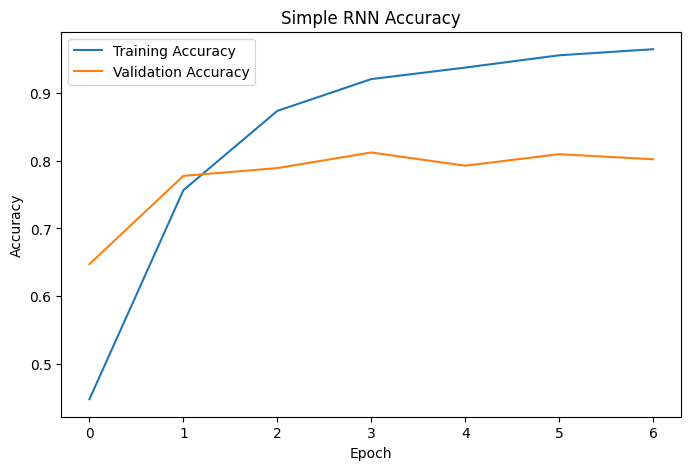

In [378]:
# Plot Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')

plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("Simple RNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

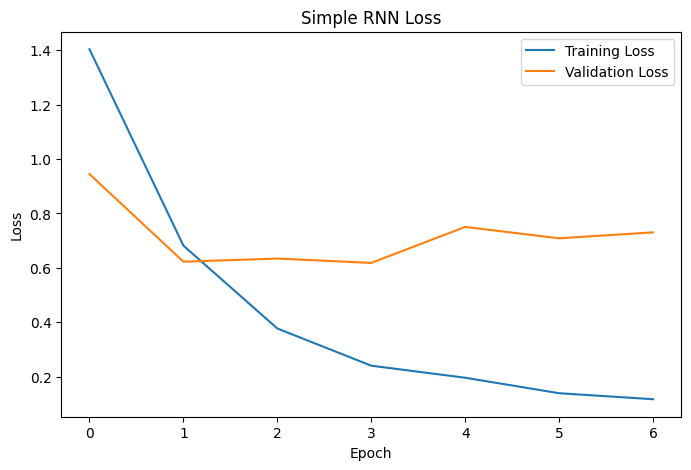

In [379]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')

plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("Simple RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [380]:
# Evaluate Model

loss, accuracy = simple_rnn.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

Test Loss : 0.6211159229278564
Test Accuracy : 0.8059999942779541


In [381]:
# Predictions

y_pred_prob = simple_rnn.predict(X_test_pad)

y_pred = y_pred_prob.argmax(axis=1)

y_true = y_test_cat.argmax(axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [382]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.75      0.67      0.71       275
        fear       0.66      0.74      0.70       224
         joy       0.85      0.92      0.88       695
        love       0.62      0.58      0.60       159
     sadness       0.90      0.87      0.89       581
    surprise       0.61      0.33      0.43        66

    accuracy                           0.81      2000
   macro avg       0.73      0.69      0.70      2000
weighted avg       0.80      0.81      0.80      2000



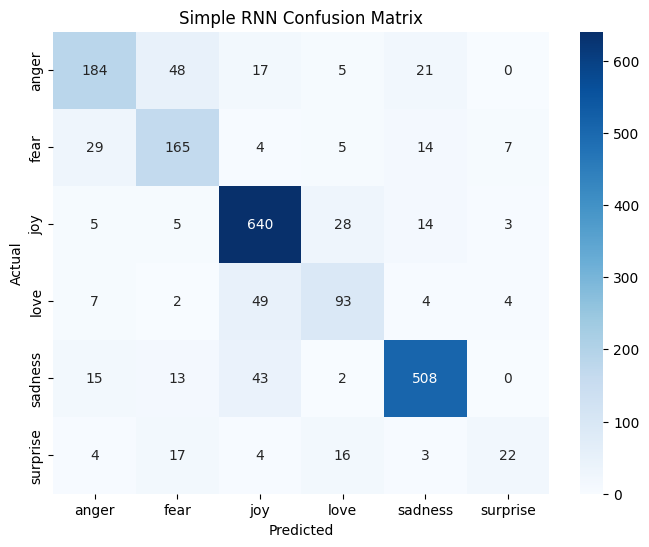

In [383]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Simple RNN Confusion Matrix")

plt.show()

In [384]:
# Calculate Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.806
Precision : 0.8028433063685965
Recall : 0.806
F1 Score : 0.8018221681595785


In [493]:
# Check Overfitting

train_acc = history_rnn.history['accuracy'][-1]
val_acc = history_rnn.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.10:
    print("Model is Overfitting")

elif train_acc < 0.70 and val_acc < 0.70:
    print("Model is Underfitting")

else:
    print("Model is Well Fitted")

Training Accuracy : 0.9641852378845215
Validation Accuracy : 0.8019999861717224
Model is Overfitting


In [494]:
rnn_results = {
    "Model": "Simple RNN",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [495]:
simple_rnn.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Simple_RNN.keras"
)

# Long Short-Term Memory(LSTM)

In [496]:
# Import Library

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [497]:
# Build the LSTM Model

lstm_model = Sequential()

# Embedding Layer
lstm_model.add(
    Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=128,
    mask_zero=True
)
)

# LSTM Layer
lstm_model.add(
    LSTM(
    128,
    dropout=0.3
)
)

# Dropout Layer
lstm_model.add(
    Dropout(0.3)
)

# Hidden Layer
lstm_model.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
lstm_model.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [498]:
# Model Summary

lstm_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [499]:
# Compile the Model
from tensorflow.keras.optimizers import Adam

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [500]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [501]:
# Train the Model

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5700 - loss: 1.1212 - val_accuracy: 0.8080 - val_loss: 0.5887
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8971 - loss: 0.3037 - val_accuracy: 0.9035 - val_loss: 0.2783
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9511 - loss: 0.1407 - val_accuracy: 0.9110 - val_loss: 0.2493
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9662 - loss: 0.0938 - val_accuracy: 0.9090 - val_loss: 0.2725
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9746 - loss: 0.0711 - val_accuracy: 0.9120 - val_loss: 0.2851
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9786 - loss: 0.0620 - val_accuracy: 0.9130 - val_loss: 0.2970
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9821 - loss: 0.0526 - val_accuracy: 0.9125 - val_loss: 0.3186
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9849 - loss: 0.0400 - val_accuracy:

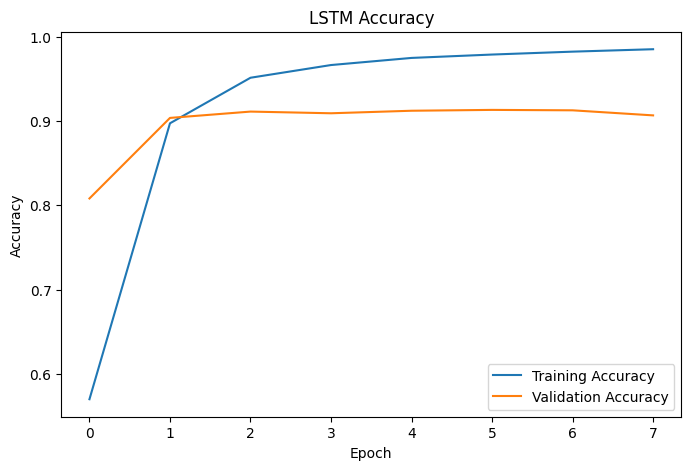

In [502]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

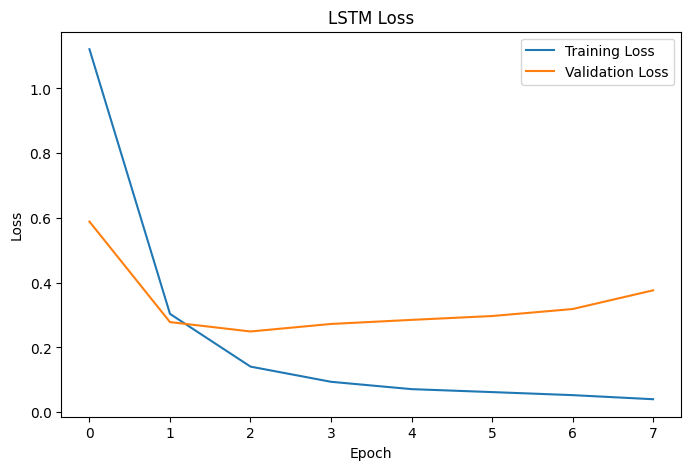

In [503]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [504]:
# Evaluate Model

loss, accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.25822997093200684
Test Accuracy : 0.906000018119812


In [505]:
# Predictions

y_pred_prob = lstm_model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [506]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.90      0.91      0.90       275
        fear       0.90      0.84      0.87       224
         joy       0.92      0.93      0.93       695
        love       0.77      0.86      0.81       159
     sadness       0.96      0.93      0.95       581
    surprise       0.65      0.74      0.70        66

    accuracy                           0.91      2000
   macro avg       0.85      0.87      0.86      2000
weighted avg       0.91      0.91      0.91      2000



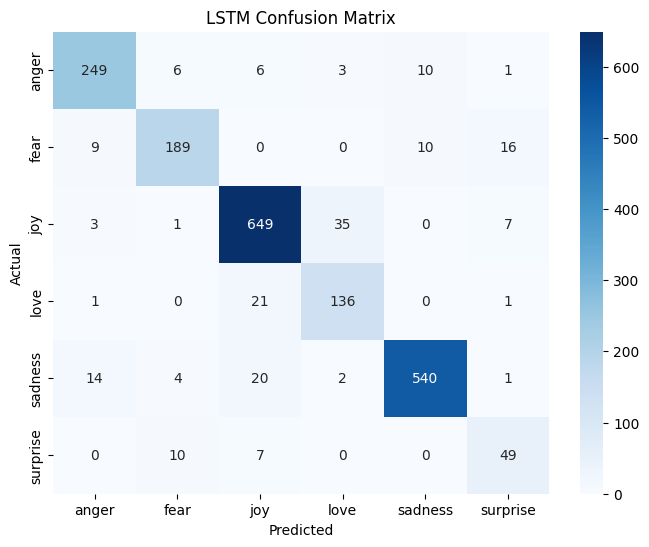

In [507]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

In [508]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.906
Precision : 0.9087729858483404
Recall : 0.906
F1 Score : 0.9069202448976426


In [509]:
lstm_results = {
    "Model": "LSTM",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [510]:
# Check Overfitting

train_acc = history_lstm.history['accuracy'][-1]
val_acc = history_lstm.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc-val_acc>0.05:
    print("Model is Overfitting")
elif val_acc-train_acc>0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.984936535358429
Validation Accuracy : 0.906499981880188
Model is Overfitting


In [511]:
lstm_model.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/LSTM.keras"
)

# GRU

In [512]:
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

In [513]:
gru_model = Sequential()

# Embedding Layer
gru_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# GRU Layer
gru_model.add(
    GRU(
        units=64,
        dropout=0.3
    )
)

# Dropout Layer
gru_model.add(
    Dropout(0.3)
)

# Hidden Layer
gru_model.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
gru_model.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [514]:
# Model Summary

gru_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [515]:
# Compile Model

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [516]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [517]:
# Train Model

history_gru = gru_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5054 - loss: 1.2308 - val_accuracy: 0.8235 - val_loss: 0.5029
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8964 - loss: 0.2995 - val_accuracy: 0.9065 - val_loss: 0.2657
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9462 - loss: 0.1437 - val_accuracy: 0.9165 - val_loss: 0.2256
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9619 - loss: 0.0965 - val_accuracy: 0.9190 - val_loss: 0.2477
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9703 - loss: 0.0788 - val_accuracy: 0.9265 - val_loss: 0.2438
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9779 - loss: 0.0591 - val_accuracy: 0.9205 - val_loss: 0.2703
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9801 - loss: 0.0511 - val_accuracy: 0.9215 - val_loss: 0.2747
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9824 - loss: 0.0481 - val_accuracy:

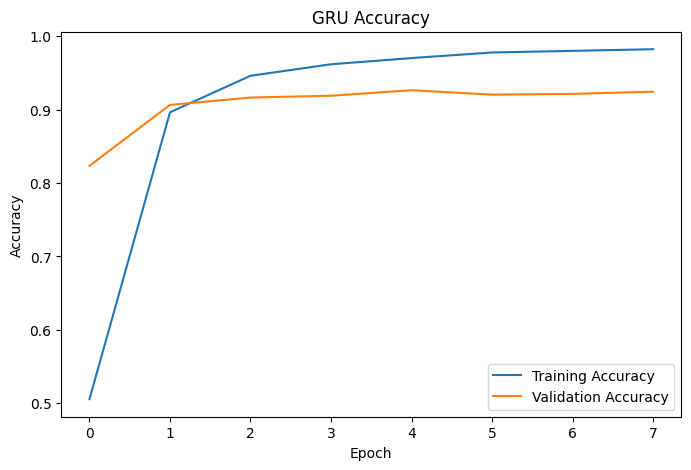

In [518]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')

plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

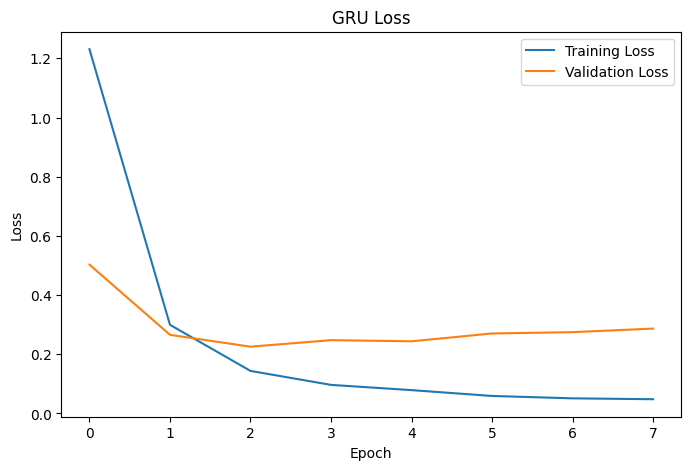

In [519]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [520]:
# Evaluate Model

loss, accuracy = gru_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.2039216309785843
Test Accuracy : 0.9125000238418579


In [521]:
# Predictions

y_pred_prob = gru_model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [522]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.90      0.91      0.90       275
        fear       0.90      0.86      0.88       224
         joy       0.96      0.92      0.94       695
        love       0.74      0.91      0.81       159
     sadness       0.96      0.94      0.95       581
    surprise       0.71      0.82      0.76        66

    accuracy                           0.91      2000
   macro avg       0.86      0.89      0.87      2000
weighted avg       0.92      0.91      0.91      2000



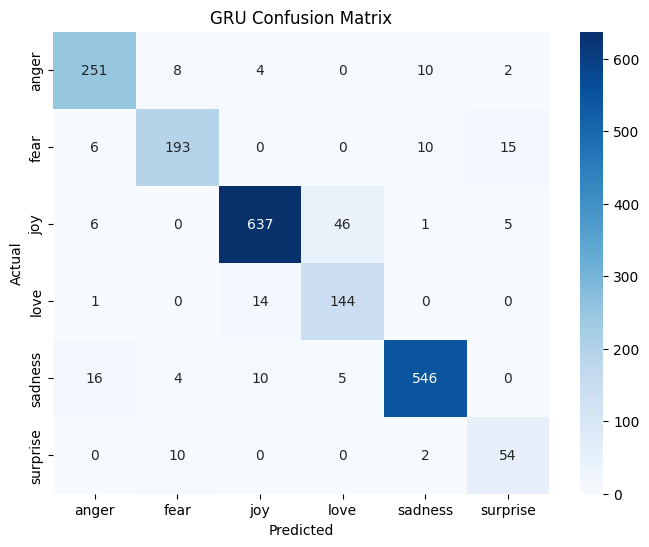

In [523]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")

plt.show()

In [524]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)


Accuracy : 0.9125
Precision : 0.9175794144808143
Recall : 0.9125
F1 Score : 0.9139987178755353


In [527]:
# Check Overfitting

train_acc = history_gru.history['accuracy'][-1]
val_acc = history_gru.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9823738932609558
Validation Accuracy : 0.9244999885559082
Model is Overfitting


In [528]:
gru_results = {
    "Model": "GRU",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [529]:
gru_model.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/GRU.keras"
)

# Bidirectional Simple RNN

In [530]:
# Import Libarary

from tensorflow.keras.layers import Bidirectional

In [531]:
# Build the Model

bi_rnn_model = Sequential()

# Embedding Layer
bi_rnn_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# Bidirectional RNN Layer
bi_rnn_model.add(
    Bidirectional(
        SimpleRNN(
            units=64,
            dropout=0.3
        )
    )
)

# Dropout Layer
bi_rnn_model.add(
    Dropout(0.3)
)

# Hidden Layer
bi_rnn_model.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
bi_rnn_model.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [532]:
# Model Summary

bi_rnn_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [533]:
# Compile Model

bi_rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [534]:
# Early Stopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [535]:
# Train Model

history_bi_rnn = bi_rnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.5112 - loss: 1.2479 - val_accuracy: 0.7945 - val_loss: 0.6250
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8731 - loss: 0.3757 - val_accuracy: 0.8700 - val_loss: 0.3991
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9409 - loss: 0.1733 - val_accuracy: 0.8660 - val_loss: 0.4005
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9652 - loss: 0.1063 - val_accuracy: 0.8705 - val_loss: 0.4652
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9752 - loss: 0.0742 - val_accuracy: 0.8635 - val_loss: 0.4928
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9822 - loss: 0.0558 - val_accuracy: 0.8695 - val_loss: 0.5317
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9846 - loss: 0.0502 - val_accuracy: 0.8715 - val_loss: 0.5466


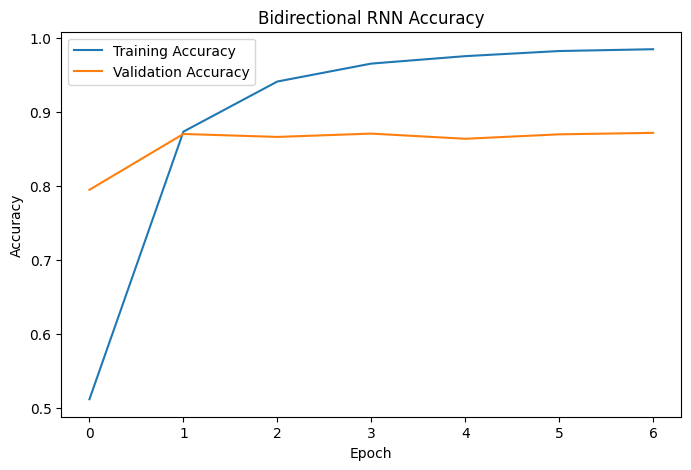

In [536]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_bi_rnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bi_rnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Bidirectional RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

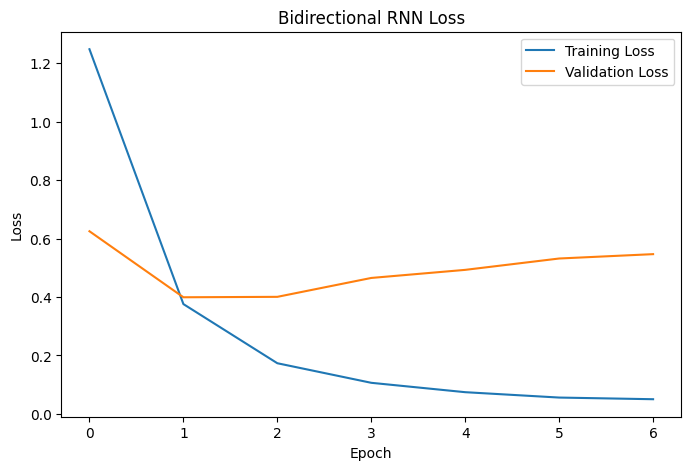

In [537]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_bi_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bi_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("Bidirectional RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [538]:
# Evaluate Model

loss, accuracy = bi_rnn_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.3844352960586548
Test Accuracy : 0.862500011920929


In [539]:
# Predictions

y_pred_prob = bi_rnn_model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [540]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.84      0.86      0.85       275
        fear       0.87      0.80      0.84       224
         joy       0.90      0.91      0.90       695
        love       0.67      0.70      0.69       159
     sadness       0.91      0.91      0.91       581
    surprise       0.59      0.53      0.56        66

    accuracy                           0.86      2000
   macro avg       0.80      0.79      0.79      2000
weighted avg       0.86      0.86      0.86      2000



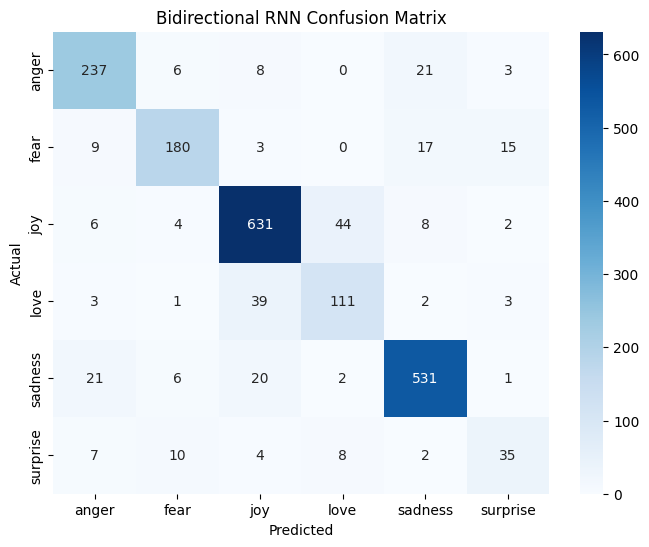

In [541]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bidirectional RNN Confusion Matrix")

plt.show()

In [542]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.8625
Precision : 0.8621243930895655
Recall : 0.8625
F1 Score : 0.8620496100531873


In [544]:
birnn_results = {
    "Model": "Bi-RNN",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [545]:
# Check Overfitting

train_acc = history_bi_rnn.history["accuracy"][-1]
val_acc = history_bi_rnn.history["val_accuracy"][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9846240282058716
Validation Accuracy : 0.8715000152587891
Model is Overfitting


In [546]:
bi_rnn_model.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Bidirectional_RNN.keras"
)

# Bidirectional LSTM(BiLSTM)

In [547]:
# Build the Model

bi_lstm_model = Sequential()

# Embedding Layer
bi_lstm_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# Bidirectional LSTM Layer
bi_lstm_model.add(
    Bidirectional(
        LSTM(
            units=64,
            dropout=0.3
        )
    )
)

# Dropout Layer
bi_lstm_model.add(
    Dropout(0.3)
)

# Hidden Layer
bi_lstm_model.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
bi_lstm_model.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [548]:
# Model Summary

bi_lstm_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [549]:
# Compile Model

bi_lstm_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [550]:
# Early Stopping

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)



In [551]:
# Train Model

history_bilstm = bi_lstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5777 - loss: 1.0966 - val_accuracy: 0.8470 - val_loss: 0.4517
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9079 - loss: 0.2734 - val_accuracy: 0.8900 - val_loss: 0.3068
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9550 - loss: 0.1303 - val_accuracy: 0.8985 - val_loss: 0.3002
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9696 - loss: 0.0864 - val_accuracy: 0.9055 - val_loss: 0.2893
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9766 - loss: 0.0652 - val_accuracy: 0.8990 - val_loss: 0.3175
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9814 - loss: 0.0513 - val_accuracy: 0.9020 - val_loss: 0.3354
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9837 - loss: 0.0447 - val_accuracy: 0.9055 - val_loss: 0.3611
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9856 - loss: 0.0389 - val_accu

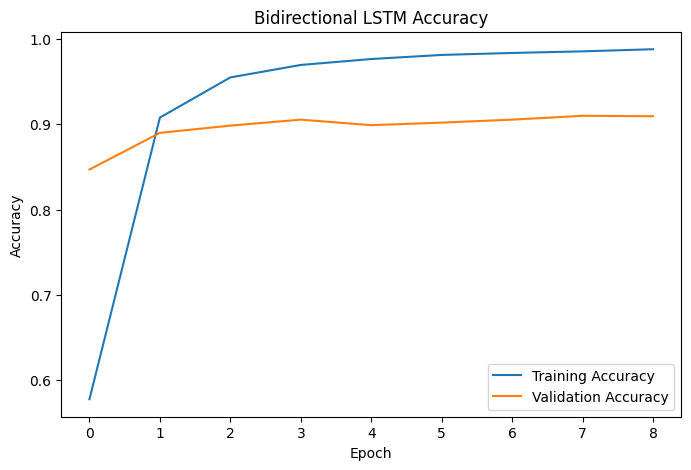

In [552]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_bilstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Bidirectional LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

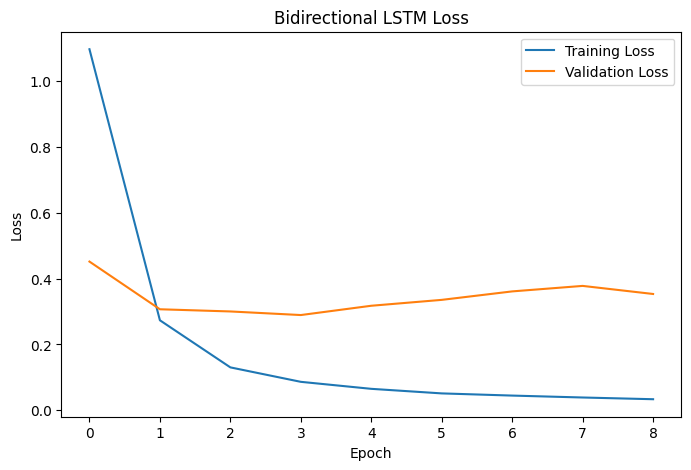

In [553]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_bilstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("Bidirectional LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [554]:
# Evaluate Model

loss, accuracy = bi_lstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)


Test Loss : 0.2943281829357147
Test Accuracy : 0.9010000228881836


In [555]:
# Predictions

y_pred_prob = bi_lstm_model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [556]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.88      0.89      0.88       275
        fear       0.85      0.89      0.87       224
         joy       0.94      0.92      0.93       695
        love       0.74      0.84      0.79       159
     sadness       0.96      0.93      0.94       581
    surprise       0.71      0.68      0.70        66

    accuracy                           0.90      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.90      0.90      0.90      2000



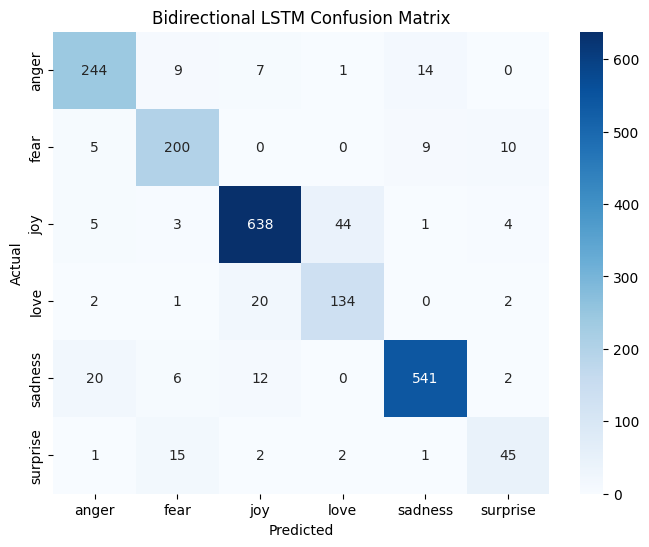

In [557]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Bidirectional LSTM Confusion Matrix")

plt.show()


In [558]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.901
Precision : 0.9034590760498619
Recall : 0.901
F1 Score : 0.9018147173004317


In [560]:
bilstm_results = {
    "Model": "Bi-LSTM",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [559]:
# Check Overfitting

train_acc = history_bilstm.history['accuracy'][-1]
val_acc = history_bilstm.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9880617260932922
Validation Accuracy : 0.909500002861023
Model is Overfitting


In [561]:
# Save Model

bi_lstm_model.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Bidirectional_LSTM.keras"
)

# Bidirectional GRU(BiGRU)

In [562]:
# Build the Model

bi_gru_model = Sequential()

# Embedding Layer
bi_gru_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# Bidirectional GRU Layer
bi_gru_model.add(
    Bidirectional(
        GRU(
            units=64,
            dropout=0.3
        )
    )
)

# Dropout Layer
bi_gru_model.add(
    Dropout(0.3)
)

# Hidden Layer
bi_gru_model.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
bi_gru_model.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)



In [563]:
# Model Summary

bi_gru_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [564]:
# Compile Model

bi_gru_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [565]:
# Early Stopping

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

In [566]:
# Train Model

history_bigru = bi_gru_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5611 - loss: 1.1126 - val_accuracy: 0.8390 - val_loss: 0.4414
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9155 - loss: 0.2414 - val_accuracy: 0.9155 - val_loss: 0.2356
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9564 - loss: 0.1132 - val_accuracy: 0.9180 - val_loss: 0.2479
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9746 - loss: 0.0723 - val_accuracy: 0.9100 - val_loss: 0.2825
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9780 - loss: 0.0573 - val_accuracy: 0.9125 - val_loss: 0.3044
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9829 - loss: 0.0463 - val_accuracy: 0.9210 - val_loss: 0.3181
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9856 - loss: 0.0391 - val_accuracy: 0.9160 - val_loss: 0.3772


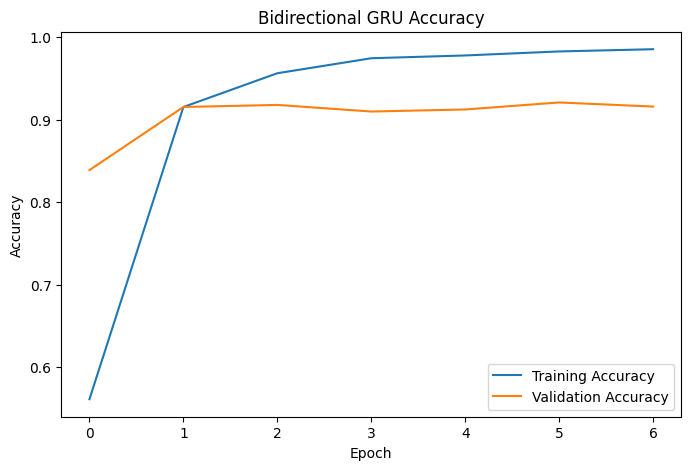

In [567]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_bigru.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_bigru.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Bidirectional GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


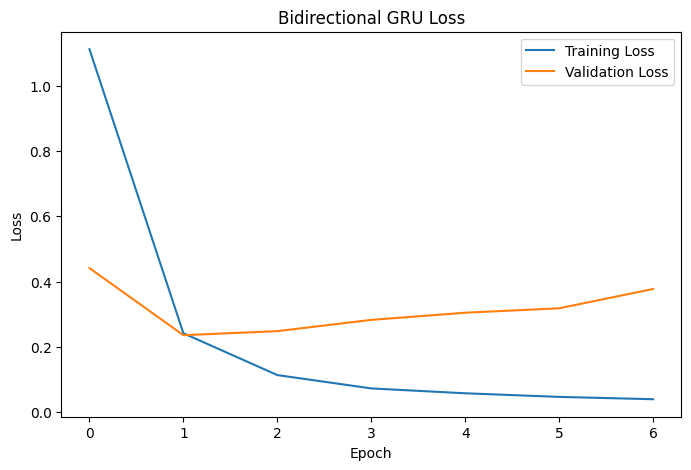

In [568]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_bigru.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_bigru.history['val_loss'],
    label='Validation Loss'
)

plt.title("Bidirectional GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [569]:
# Evaluate Model

loss, accuracy = bi_gru_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.22014163434505463
Test Accuracy : 0.9104999899864197


In [570]:
# Predictions

y_pred_prob = bi_gru_model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [571]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.90      0.89      0.90       275
        fear       0.83      0.92      0.87       224
         joy       0.93      0.95      0.94       695
        love       0.82      0.72      0.77       159
     sadness       0.96      0.95      0.95       581
    surprise       0.81      0.65      0.72        66

    accuracy                           0.91      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.91      0.91      0.91      2000



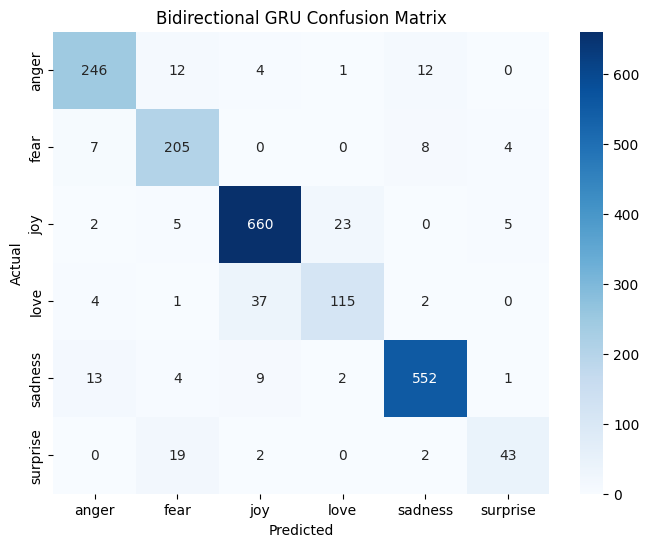

In [572]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bidirectional GRU Confusion Matrix")

plt.show()

In [573]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9105
Precision : 0.9098205812681548
Recall : 0.9105
F1 Score : 0.9093809888422182


In [574]:
bigru_results = {
    "Model": "Bi-GRU",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [575]:
# Check Overfitting

train_acc = history_bigru.history['accuracy'][-1]
val_acc = history_bigru.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9855616092681885
Validation Accuracy : 0.9160000085830688
Model is Overfitting


In [576]:
# Save Model

bi_gru_model.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Bidirectional_GRU.keras"
)

# Stacked RNN

In [577]:
# Build the stacked RNN Model

stacked_rnn = Sequential()

# Embedding Layer
stacked_rnn.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# First RNN Layer
stacked_rnn.add(
    SimpleRNN(
        128,
        return_sequences=True,
        dropout=0.3
    )
)

# Second RNN Layer
stacked_rnn.add(
    SimpleRNN(
        64,
        dropout=0.3
    )
)

# Dropout Layer
stacked_rnn.add(
    Dropout(0.3)
)

# Hidden Layer
stacked_rnn.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
stacked_rnn.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [578]:
# Model Summary

stacked_rnn.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [579]:
# Compile Model

stacked_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [580]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [581]:
# Train Model

history_stacked_rnn = stacked_rnn.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.3855 - loss: 1.4793 - val_accuracy: 0.6655 - val_loss: 0.9709
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7802 - loss: 0.6457 - val_accuracy: 0.8310 - val_loss: 0.5025
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8941 - loss: 0.3147 - val_accuracy: 0.8620 - val_loss: 0.4347
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9297 - loss: 0.2036 - val_accuracy: 0.8645 - val_loss: 0.4721
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9543 - loss: 0.1365 - val_accuracy: 0.8600 - val_loss: 0.5256
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9589 - loss: 0.1247 - val_accuracy: 0.8550 - val_loss: 0.5397
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9683 - loss: 0.0964 - val_accuracy: 0.8610 - val_loss: 0.5524
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9726 - loss: 0.0842 - val_accurac

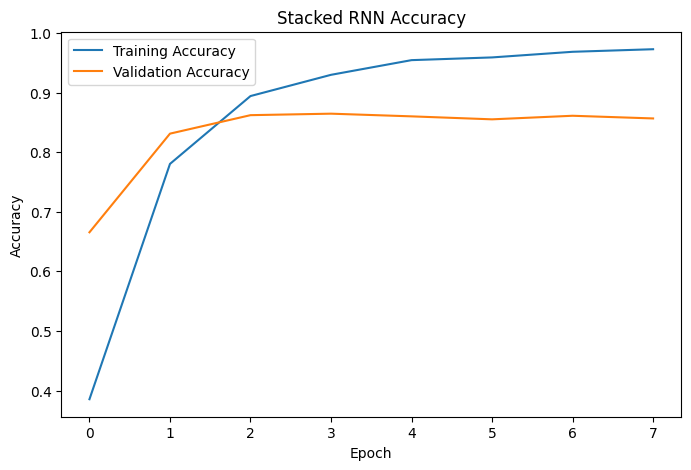

In [582]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history_stacked_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_stacked_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("Stacked RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

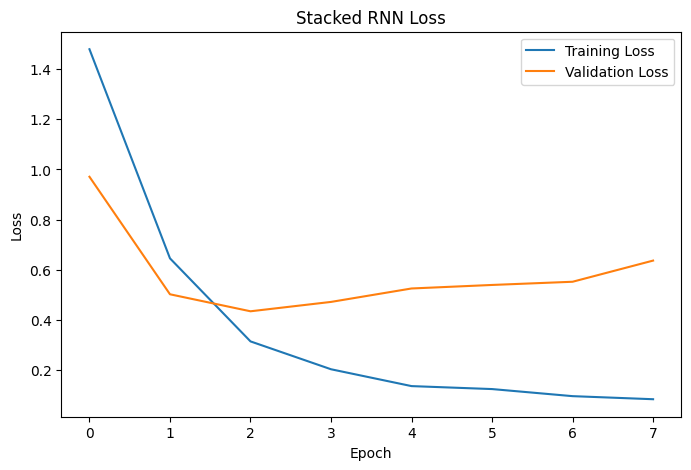

In [583]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history_stacked_rnn.history['loss'], label='Training Loss')
plt.plot(history_stacked_rnn.history['val_loss'], label='Validation Loss')

plt.title("Stacked RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [584]:
# Evaluate Model

loss, accuracy = stacked_rnn.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.4958869218826294
Test Accuracy : 0.8464999794960022


In [585]:
# Predictions

y_pred_prob = stacked_rnn.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [586]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.75      0.91      0.82       275
        fear       0.90      0.75      0.82       224
         joy       0.92      0.85      0.89       695
        love       0.62      0.85      0.72       159
     sadness       0.92      0.87      0.89       581
    surprise       0.62      0.62      0.62        66

    accuracy                           0.85      2000
   macro avg       0.79      0.81      0.79      2000
weighted avg       0.86      0.85      0.85      2000



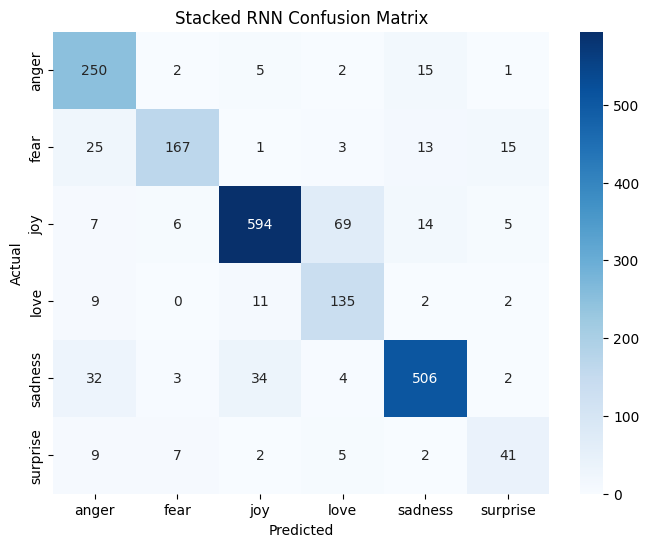

In [587]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacked RNN Confusion Matrix")
plt.show()

In [588]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.8465
Precision : 0.8596991804632123
Recall : 0.8465
F1 Score : 0.8492590651738653


In [589]:
stacked_rnn_results = {
    "Model": "Stacked RNN",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [590]:
# Check Overfitting

train_acc = history_stacked_rnn.history['accuracy'][-1]
val_acc = history_stacked_rnn.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9726232886314392
Validation Accuracy : 0.8565000295639038
Model is Overfitting


In [591]:
# Save Model

stacked_rnn.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Stacked_RNN.keras"
)

# Stacked LSTM

In [592]:
# Build the Model

stacked_lstm = Sequential()

# Embedding Layer
stacked_lstm.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# First LSTM Layer
stacked_lstm.add(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.3
    )
)

# Second LSTM Layer
stacked_lstm.add(
    LSTM(
        64,
        dropout=0.3
    )
)

# Dropout Layer
stacked_lstm.add(
    Dropout(0.3)
)

# Hidden Layer
stacked_lstm.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
stacked_lstm.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [593]:
# Model Summary

stacked_lstm.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [594]:
# Compile Model

stacked_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [595]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [596]:
# Train Model

history_stacked_lstm = stacked_lstm.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.4872 - loss: 1.2419 - val_accuracy: 0.8045 - val_loss: 0.5998
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8796 - loss: 0.3605 - val_accuracy: 0.8980 - val_loss: 0.2870
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9339 - loss: 0.1909 - val_accuracy: 0.9195 - val_loss: 0.2358
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9559 - loss: 0.1251 - val_accuracy: 0.9205 - val_loss: 0.2631
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9641 - loss: 0.0974 - val_accuracy: 0.9120 - val_loss: 0.2943
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9704 - loss: 0.0804 - val_accuracy: 0.9200 - val_loss: 0.2816
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9759 - loss: 0.0654 - val_accuracy: 0.9130 - val_loss: 0.3086
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9780 - loss: 0.0634 - val_acc

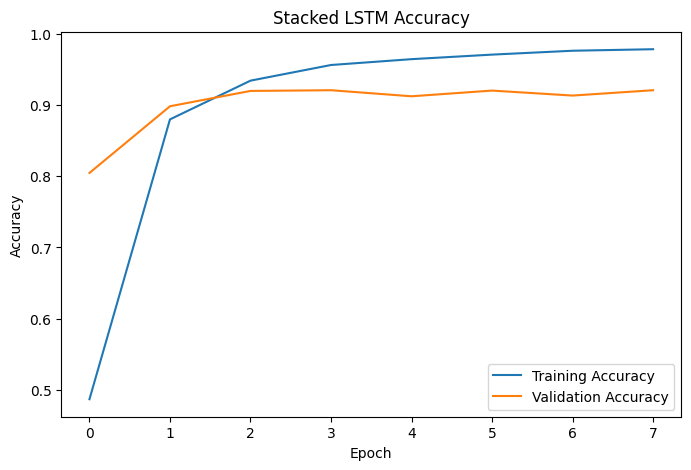

In [597]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_stacked_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_stacked_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Stacked LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

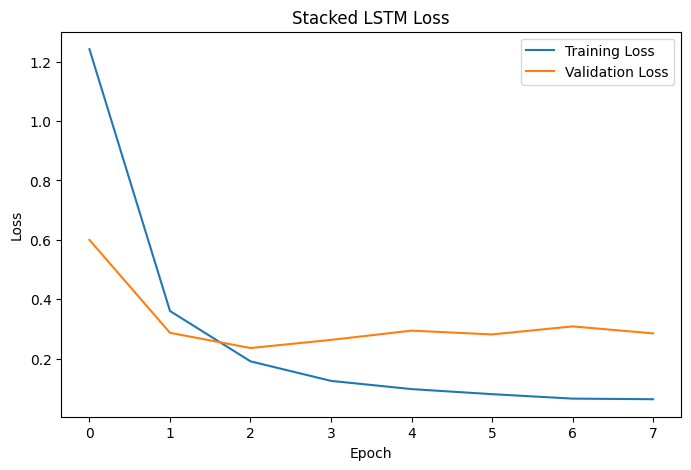

In [598]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(
    history_stacked_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_stacked_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("Stacked LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [599]:
# Evaluate Model

loss, accuracy = stacked_lstm.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.22789888083934784
Test Accuracy : 0.9120000004768372


In [600]:
# Predictions

y_pred_prob = stacked_lstm.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [601]:
# Classification Model

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.92      0.91      0.91       275
        fear       0.88      0.86      0.87       224
         joy       0.95      0.92      0.94       695
        love       0.75      0.84      0.79       159
     sadness       0.97      0.95      0.96       581
    surprise       0.66      0.83      0.74        66

    accuracy                           0.91      2000
   macro avg       0.85      0.89      0.87      2000
weighted avg       0.92      0.91      0.91      2000



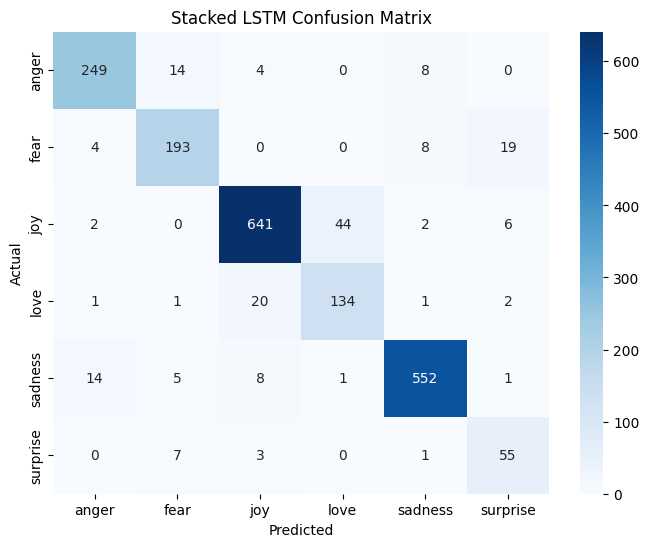

In [602]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacked LSTM Confusion Matrix")
plt.show()

In [603]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.912
Precision : 0.9162923308073979
Recall : 0.912
F1 Score : 0.9135055185805734


In [604]:
stacked_lstm_results = {
    "Model": "Stacked LSTM",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [605]:
# Check Overfitting

train_acc = history_stacked_lstm.history['accuracy'][-1]
val_acc = history_stacked_lstm.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9779986143112183
Validation Accuracy : 0.9204999804496765
Model is Overfitting


In [606]:
# Save Model

stacked_lstm.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Stacked_LSTM.keras"
)

# Stacked GRU

In [607]:
# Build the Model

stacked_gru = Sequential()

# Embedding Layer
stacked_gru.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    )
)

# First GRU Layer
stacked_gru.add(
    GRU(
        128,
        return_sequences=True,
        dropout=0.3
    )
)

# Second GRU Layer
stacked_gru.add(
    GRU(
        64,
        dropout=0.3
    )
)

# Dropout Layer
stacked_gru.add(
    Dropout(0.3)
)

# Hidden Layer
stacked_gru.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
stacked_gru.add(
    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
)

In [608]:
# Model Summary

stacked_gru.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [609]:
# Compile Model

stacked_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [610]:
# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [611]:
# Train Model

history_stacked_gru = stacked_gru.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5633 - loss: 1.0869 - val_accuracy: 0.8730 - val_loss: 0.3846
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9085 - loss: 0.2673 - val_accuracy: 0.9130 - val_loss: 0.2543
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9452 - loss: 0.1526 - val_accuracy: 0.9225 - val_loss: 0.2241
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9589 - loss: 0.1087 - val_accuracy: 0.9175 - val_loss: 0.2597
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9657 - loss: 0.0890 - val_accuracy: 0.9230 - val_loss: 0.2438
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9749 - loss: 0.0705 - val_accuracy: 0.9165 - val_loss: 0.2776
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9759 - loss: 0.0650 - val_accuracy: 0.9210 - val_loss: 0.2819
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9792 - loss: 0.0583 - val_accu

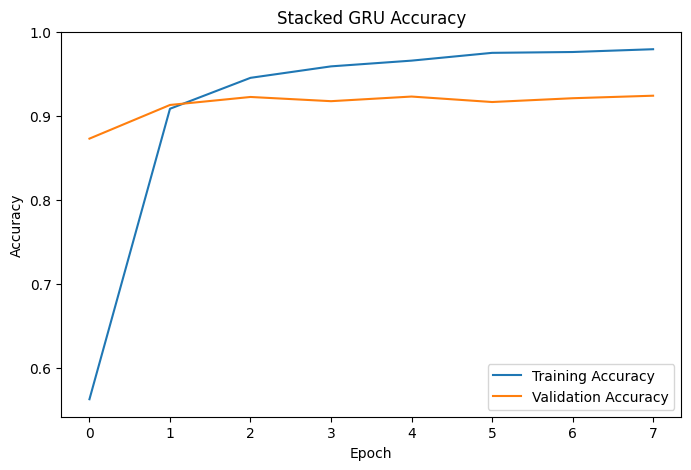

In [612]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history_stacked_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_stacked_gru.history['val_accuracy'], label='Validation Accuracy')

plt.title("Stacked GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

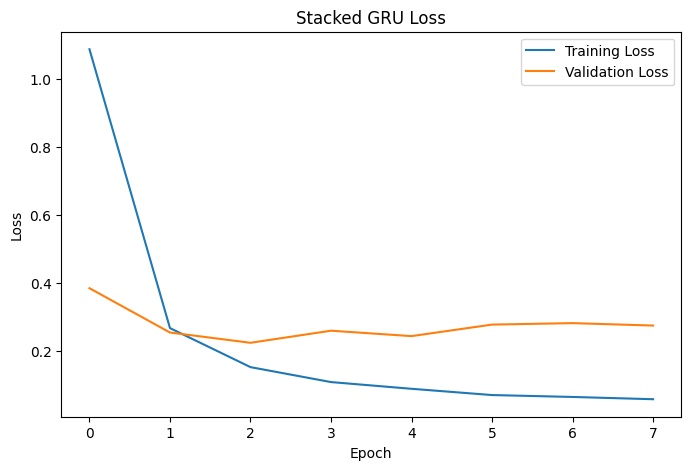

In [613]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history_stacked_gru.history['loss'], label='Training Loss')
plt.plot(history_stacked_gru.history['val_loss'], label='Validation Loss')

plt.title("Stacked GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [614]:
# Evaluate Model

loss, accuracy = stacked_gru.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.22194668650627136
Test Accuracy : 0.9160000085830688


In [615]:
# Predictions

y_pred_prob = stacked_gru.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [616]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.92      0.90      0.91       275
        fear       0.89      0.92      0.90       224
         joy       0.95      0.92      0.93       695
        love       0.72      0.86      0.78       159
     sadness       0.97      0.95      0.96       581
    surprise       0.77      0.73      0.75        66

    accuracy                           0.92      2000
   macro avg       0.87      0.88      0.87      2000
weighted avg       0.92      0.92      0.92      2000



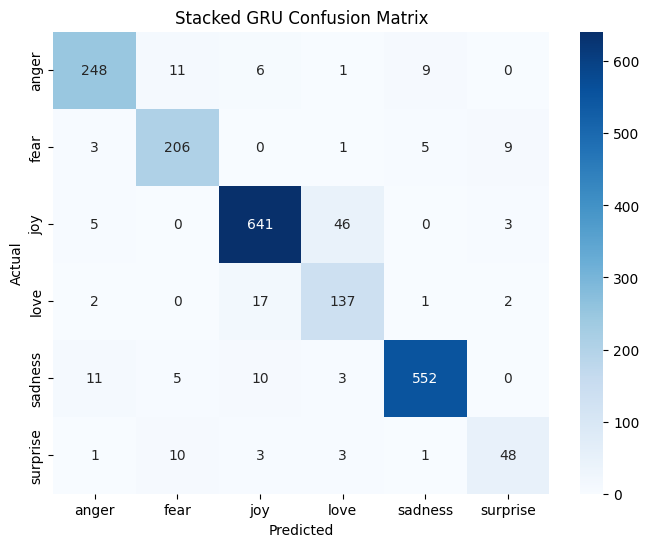

In [617]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacked GRU Confusion Matrix")

plt.show()

In [618]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.916
Precision : 0.9196548388936937
Recall : 0.916
F1 Score : 0.9171452658925089


In [619]:
stacked_gru_results = {
    "Model": "Stacked GRU",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [620]:
# Check Overfitting

train_acc = history_stacked_gru.history['accuracy'][-1]
val_acc = history_stacked_gru.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9792487025260925
Validation Accuracy : 0.9240000247955322
Model is Overfitting


In [621]:
# Save Model

stacked_gru.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/Stacked_GRU.keras"
)

In [622]:
# Install KerasTuner

!pip install -q keras-tuner

In [623]:
import keras_tuner as kt

In [624]:
# Create Model Building Function

def build_lstm_model(hp):

    model = Sequential()

    # Embedding Layer
    model.add(
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            mask_zero=True
        )
    )

    # LSTM Layer
    model.add(
        LSTM(
            units=hp.Choice(
                "lstm_units",
                values=[32,64,128]
            ),
            dropout=hp.Choice(
                "dropout",
                values=[0.2,0.3,0.4]
            )
        )
    )

    # Dense Layer
    model.add(
        Dense(
            hp.Choice(
                "dense_units",
                values=[32,64,128]
            ),
            activation="relu"
        )
    )

    # Output Layer
    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )

    # Compile

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                values=[1e-2,1e-3,1e-4]
            )
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [625]:
# Create the Tuner

tuner = kt.RandomSearch(

    build_lstm_model,

    objective="val_accuracy",

    max_trials=10,

    executions_per_trial=1,

    directory="keras_tuner",

    project_name="Emotion_LSTM_Tuning"
)

Reloading Tuner from keras_tuner/Emotion_LSTM_Tuning/tuner0.json


In [626]:
# Display Search Space

tuner.search_space_summary()

Search space summary
Default search space size: 4
lstm_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4], 'ordered': True}
dense_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [627]:
# Start Hyperparameter Search

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tuner.search(

    X_train_pad,

    y_train_cat,

    validation_data=(X_val_pad,y_val_cat),

    epochs=10,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

In [628]:
# Display Best Hyperparameters

best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best LSTM Units :", best_hp.get("lstm_units"))
print("Best Dropout :", best_hp.get("dropout"))
print("Best Dense Units :", best_hp.get("dense_units"))
print("Best Learning Rate :", best_hp.get("learning_rate"))

Best LSTM Units : 128
Best Dropout : 0.2
Best Dense Units : 64
Best Learning Rate : 0.01


In [629]:
# Build the Best Model

best_model = tuner.hypermodel.build(best_hp)

In [630]:
# Train the Best Model

history_best = best_model.fit(

    X_train_pad,

    y_train_cat,

    validation_data=(X_val_pad,y_val_cat),

    epochs=20,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8181 - loss: 0.5027 - val_accuracy: 0.9135 - val_loss: 0.2166
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9395 - loss: 0.1462 - val_accuracy: 0.9145 - val_loss: 0.2088
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9576 - loss: 0.1038 - val_accuracy: 0.9210 - val_loss: 0.2034
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9706 - loss: 0.0716 - val_accuracy: 0.9115 - val_loss: 0.2776
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9785 - loss: 0.0537 - val_accuracy: 0.9185 - val_loss: 0.3116
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9792 - loss: 0.0533 - val_accuracy: 0.9250 - val_loss: 0.2915


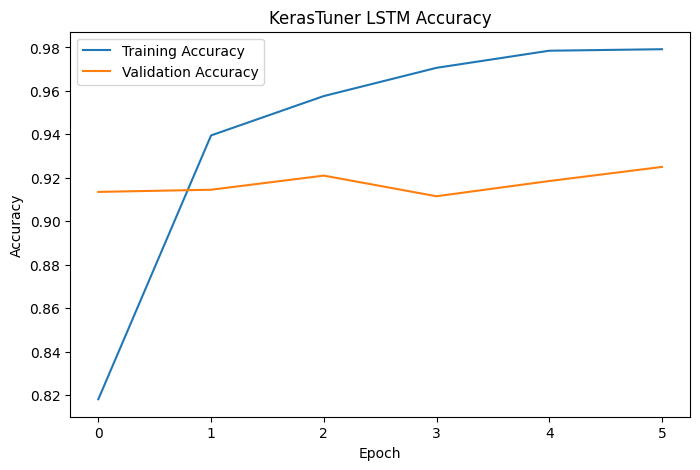

In [631]:
# Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(
    history_best.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_best.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("KerasTuner LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

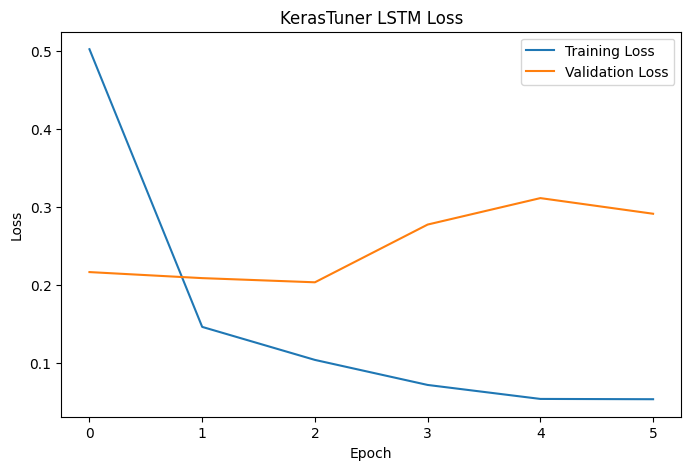

In [632]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(
    history_best.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_best.history["val_loss"],
    label="Validation Loss"
)

plt.title("KerasTuner LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [633]:
# Evaluate the Best Model

loss, accuracy = best_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Test Loss : 0.20798303186893463
Test Accuracy : 0.9190000295639038


In [634]:
# Predictions

y_pred_prob = best_model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [635]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.88      0.95      0.91       275
        fear       0.88      0.91      0.89       224
         joy       0.92      0.97      0.94       695
        love       0.91      0.70      0.79       159
     sadness       0.96      0.96      0.96       581
    surprise       0.95      0.56      0.70        66

    accuracy                           0.92      2000
   macro avg       0.92      0.84      0.87      2000
weighted avg       0.92      0.92      0.92      2000



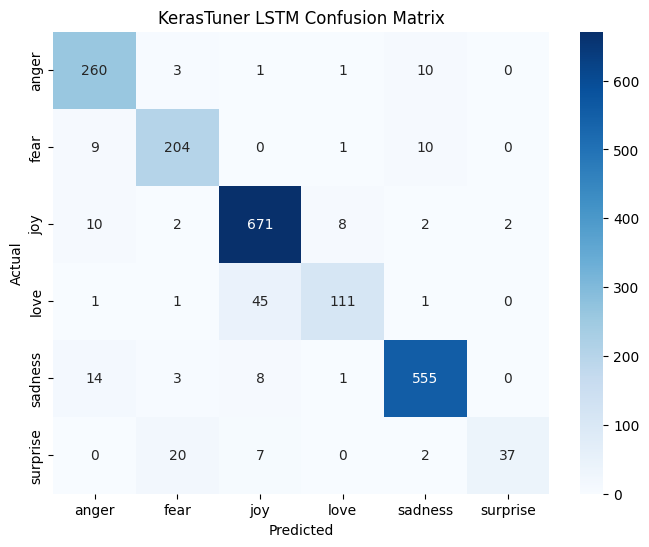

In [636]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KerasTuner LSTM Confusion Matrix")

plt.show()

In [637]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.919
Precision : 0.9198184997560278
Recall : 0.919
F1 Score : 0.9162552694370583


In [638]:
tuned_lstm_results = {
    "Model": "Tuned LSTM",
    "Loss": loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [639]:
# Check Overfitting

train_acc = history_best.history["accuracy"][-1]
val_acc = history_best.history["val_accuracy"][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

if train_acc - val_acc > 0.05:
    print("Model is Overfitting")
elif val_acc - train_acc > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Training Accuracy : 0.9791861772537231
Validation Accuracy : 0.925000011920929
Model is Overfitting


In [640]:
# Save the Tuned Model

best_model.save(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/LSTM_KerasTuner.keras"
)

In [642]:
# Install Required Libraries

!pip install -q transformers datasets accelerate evaluate

In [643]:
!pip install -q datasets

In [644]:
# Imports

import os
import re
import string
import joblib
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [645]:
# Load Dataset

dataset_path = "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Dataset"

train_df = pd.read_csv(
    os.path.join(dataset_path, "train.txt"),
    sep=";",
    names=["Text","Emotion"]
)

val_df = pd.read_csv(
    os.path.join(dataset_path, "val.txt"),
    sep=";",
    names=["Text","Emotion"]
)

test_df = pd.read_csv(
    os.path.join(dataset_path, "test.txt"),
    sep=";",
    names=["Text","Emotion"]
)

In [646]:
# Text Cleaning

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text_bert(text):

    text = text.lower()

    text = re.sub(r"<.*?>"," ",text)

    text = re.sub(r"http\S+|www\S+"," ",text)

    text = re.sub(r"\s+"," ",text).strip()

    return text

In [647]:
# Apply Cleaning

train_df["Clean_Text_BERT"] = train_df["Text"].apply(clean_text_bert)

val_df["Clean_Text_BERT"] = val_df["Text"].apply(clean_text_bert)

test_df["Clean_Text_BERT"] = test_df["Text"].apply(clean_text_bert)

In [648]:
# Label Encoding

encoder = LabelEncoder()

train_df["Label"] = encoder.fit_transform(train_df["Emotion"])

val_df["Label"] = encoder.transform(val_df["Emotion"])

test_df["Label"] = encoder.transform(test_df["Emotion"])

In [649]:
# Verify

print(train_df.head())

print(train_df.shape)

print(train_df["Emotion"].value_counts())

print(encoder.classes_)

                                                Text  Emotion  \
0                            i didnt feel humiliated  sadness   
1  i can go from feeling so hopeless to so damned...  sadness   
2   im grabbing a minute to post i feel greedy wrong    anger   
3  i am ever feeling nostalgic about the fireplac...     love   
4                               i am feeling grouchy    anger   

                                     Clean_Text_BERT  Label  
0                            i didnt feel humiliated      4  
1  i can go from feeling so hopeless to so damned...      4  
2   im grabbing a minute to post i feel greedy wrong      0  
3  i am ever feeling nostalgic about the fireplac...      3  
4                               i am feeling grouchy      0  
(16000, 4)
Emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


# BERT

In [650]:
# Import Libraries

import torch
import evaluate

from datasets import Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)




In [651]:
# Load BERT Tokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

In [652]:
# Tokenize the Data
train_encodings = tokenizer(
    train_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [653]:
# Custom Dataset

class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [654]:
# Create Datasets

train_dataset = EmotionDataset(
    train_encodings,
    train_df["Label"].tolist()
)

val_dataset = EmotionDataset(
    val_encodings,
    val_df["Label"].tolist()
)

test_dataset = EmotionDataset(
    test_encodings,
    test_df["Label"].tolist()
)

In [655]:
# Verify

print(train_dataset[0])

{'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [656]:
# Load Model

NUM_CLASSES = len(encoder.classes_)

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [657]:
# Data Collator

data_collator = DataCollatorWithPadding(tokenizer=tokenizer
)

In [658]:
# Evaluation Metric

accuracy_metric = evaluate.load("accuracy")

In [659]:
# Compute Metrics Functio

from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [660]:
# Training Arguments

training_args = TrainingArguments(

    output_dir="./bert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none"
)

In [661]:
# Create Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [662]:
# Train the Model
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.483456,0.215405,0.929000,0.931639,0.929000,0.929182
2,0.143672,0.170139,0.935000,0.935890,0.935000,0.934325
3,0.093719,0.162194,0.941000,0.941339,0.941000,0.940999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=3000, training_loss=0.2402825673421224, metrics={'train_runtime': 862.7457, 'train_samples_per_second': 55.636, 'train_steps_per_second': 3.477, 'total_flos': 2146076617536000.0, 'train_loss': 0.2402825673421224, 'epoch': 3.0})

In [663]:
# Evaluate on Validation Set

trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.093719,0.162194,3,0.941000,0.941339,0.941000,0.940999


{'eval_loss': 0.16219402849674225,
 'eval_accuracy': 0.941,
 'eval_precision': 0.9413385921099444,
 'eval_recall': 0.941,
 'eval_f1': 0.9409989319781936}

In [664]:
# Prediction

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

In [665]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.93      0.90      0.91       275
        fear       0.85      0.92      0.88       224
         joy       0.95      0.96      0.95       695
        love       0.87      0.81      0.84       159
     sadness       0.97      0.96      0.96       581
    surprise       0.78      0.70      0.74        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



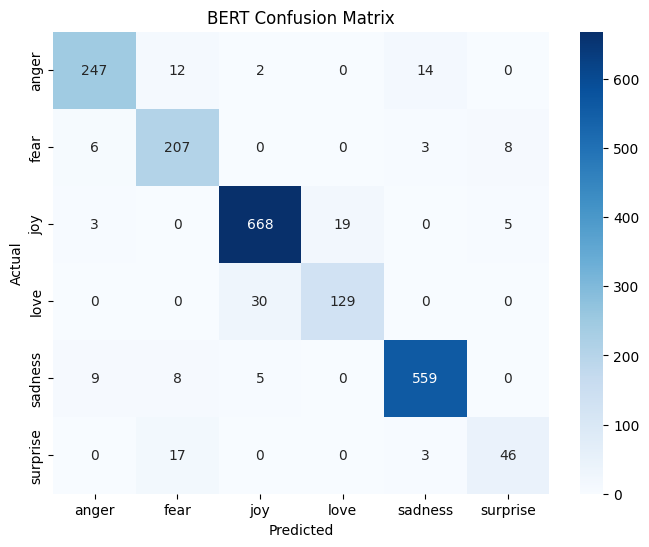

In [666]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")

plt.show()

In [732]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.932
Precision : 0.9324509943180077
Recall : 0.932
F1 Score : 0.9312171562666013


In [731]:
bert_results = {
    "Model": "BERT",
    "Loss": results["eval_loss"],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [733]:
# Save the Model

SAVE_PATH = "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/BERT"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully


In [734]:
history = pd.DataFrame(trainer.state.log_history)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.493505,4.537941,1.334000e-05,1.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1000,0.212382,0.9210,0.924262,0.9210,0.921581,8.4987,235.331,14.708,NaN,NaN,NaN,NaN,NaN
2,0.185380,5.633143,6.673333e-06,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,2000,0.165765,0.9325,0.933143,0.9325,0.931679,8.5176,234.808,14.675,NaN,NaN,NaN,NaN,NaN
4,0.126260,1.182232,6.666667e-09,3.0,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [735]:
# Prepare the Plotting

# Training history
train_history = history[history["loss"].notna()]

# Validation history
val_history = history[history["eval_loss"].notna()]

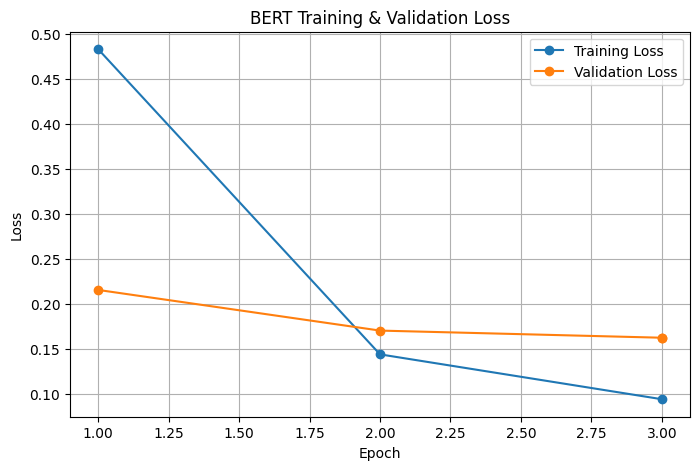

In [672]:
# Plot Loss Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_history["epoch"],
    val_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("BERT Training & Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

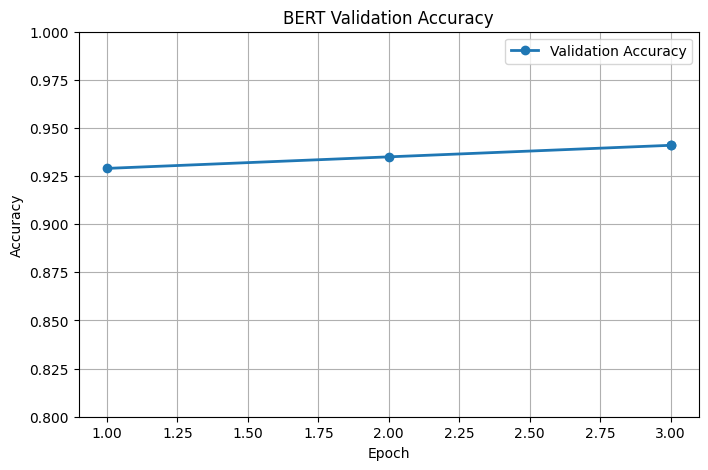

In [673]:
# Training & Validation Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(
    val_history["epoch"],
    val_history["eval_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("BERT Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.ylim(0.80,1.00)

plt.grid(True)

plt.legend()

plt.show()

In [674]:
# Save the Training Log

history.to_csv(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/BERT_Training_Log.csv",
    index=False
)

print("Training Log Saved Successfully")

Training Log Saved Successfully


In [675]:
# Overfitting Check

train_loss = train_history.iloc[-1]["loss"]

val_loss = val_history.iloc[-1]["eval_loss"]

print("Training Loss :", train_loss)

print("Validation Loss :", val_loss)

if val_loss > train_loss:
    print("Model shows signs of overfitting.")
else:
    print("Model is well fitted.")

Training Loss : 0.09371949768066407
Validation Loss : 0.16219402849674225
Model shows signs of overfitting.


# DistilBERT

In [676]:
# Import Libraries

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

In [677]:
# Load Tokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

In [678]:
# Tokenize Dataset

train_encodings = tokenizer(
    train_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [679]:
# Custome Dataset

class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [680]:
# Create Dataset

train_dataset = EmotionDataset(
    train_encodings,
    train_df["Label"].tolist()
)

val_dataset = EmotionDataset(
    val_encodings,
    val_df["Label"].tolist()
)

test_dataset = EmotionDataset(
    test_encodings,
    test_df["Label"].tolist()
)

In [681]:
# Verify Dataset

print(train_dataset[0])

{'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [682]:
# Load the DistilBERT Model

NUM_CLASSES = len(encoder.classes_)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [683]:
# Data Collator

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [684]:
# Load Accuracy Metric

accuracy_metric = evaluate.load("accuracy")

In [685]:
# Compute Metrics

from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [686]:
# Training Arguments

training_args = TrainingArguments(

    output_dir="./distilbert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none"
)

In [687]:
# Create Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [688]:
# Train the Model

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.479743,0.195842,0.930500,0.933329,0.930500,0.931080
2,0.154493,0.170597,0.933500,0.933992,0.933500,0.932802
3,0.100996,0.164864,0.941500,0.942519,0.941500,0.941529


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.24507740783691406, metrics={'train_runtime': 475.5056, 'train_samples_per_second': 100.945, 'train_steps_per_second': 6.309, 'total_flos': 1080514292544000.0, 'train_loss': 0.24507740783691406, 'epoch': 3.0})

In [689]:
# Evaluate the Model

results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.100996,0.164864,3,0.941500,0.942519,0.941500,0.941529


{'eval_loss': 0.16486398875713348, 'eval_accuracy': 0.9415, 'eval_precision': 0.9425193708720341, 'eval_recall': 0.9415, 'eval_f1': 0.9415294108817605}


In [690]:
# Prepare Training History

history = pd.DataFrame(trainer.state.log_history)

history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.479743,19.863739,1.334000e-05,1.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1000,0.195842,0.9305,0.933329,0.9305,0.931080,4.6738,427.919,26.745,NaN,NaN,NaN,NaN,NaN
2,0.154493,27.979490,6.673333e-06,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,2000,0.170597,0.9335,0.933992,0.9335,0.932802,5.4877,364.454,22.778,NaN,NaN,NaN,NaN,NaN
4,0.100996,3.558047,6.666667e-09,3.0,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,3000,0.164864,0.9415,0.942519,0.9415,0.941529,4.6802,427.336,26.709,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,475.5056,100.945,6.309,1.080514e+15,0.245077
7,NaN,NaN,NaN,3.0,3000,0.164864,0.9415,0.942519,0.9415,0.941529,4.7140,424.269,26.517,NaN,NaN,NaN,NaN,NaN


In [691]:
# Save Training Log

history.to_csv(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/DistilBERT_Training_Log.csv",
    index=False
)

print("Training Log Saved Successfully")

Training Log Saved Successfully


In [692]:
# Prepare History

train_history = history[history["loss"].notna()].copy()

val_history = history[history["eval_loss"].notna()].copy()

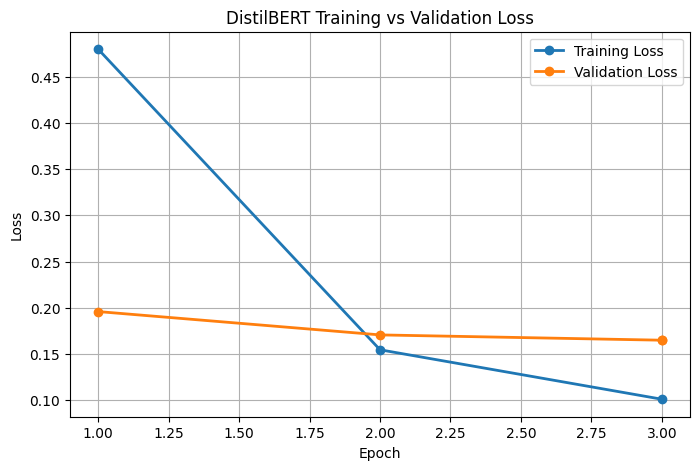

In [693]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    val_history["epoch"],
    val_history["eval_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("DistilBERT Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

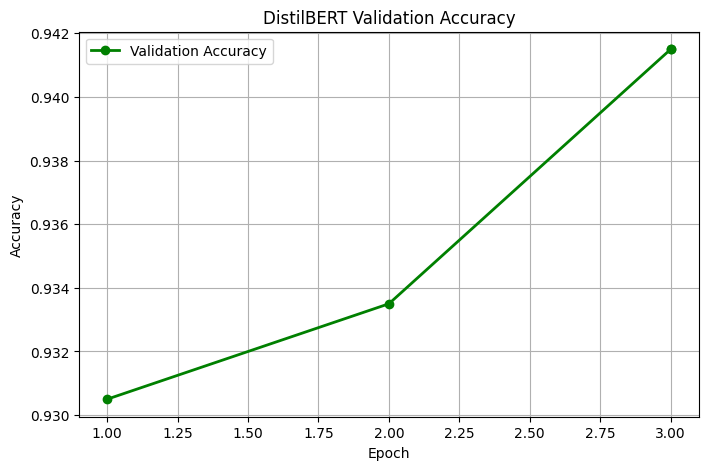

In [694]:
# Validation Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(
    val_history["epoch"],
    val_history["eval_accuracy"],
    marker="o",
    linewidth=2,
    color="green",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("DistilBERT Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [695]:
# Overfitting Check

train_loss = train_history.iloc[-1]["loss"]

val_loss = val_history.iloc[-1]["eval_loss"]

print("Final Training Loss :", round(train_loss,4))
print("Final Validation Loss :", round(val_loss,4))

if val_loss > train_loss * 1.20:
    print("Model is Overfitting")
elif train_loss > val_loss * 1.20:
    print("Model is Underfitting")
else:
    print("Model is Well Generalized")

Final Training Loss : 0.101
Final Validation Loss : 0.1649
Model is Overfitting


In [696]:
# Test Predictions

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

In [697]:
# Classification Report

print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

       anger       0.94      0.92      0.93       275
        fear       0.88      0.95      0.91       224
         joy       0.95      0.95      0.95       695
        love       0.82      0.85      0.83       159
     sadness       0.96      0.97      0.97       581
    surprise       0.89      0.62      0.73        66

    accuracy                           0.93      2000
   macro avg       0.91      0.88      0.89      2000
weighted avg       0.93      0.93      0.93      2000



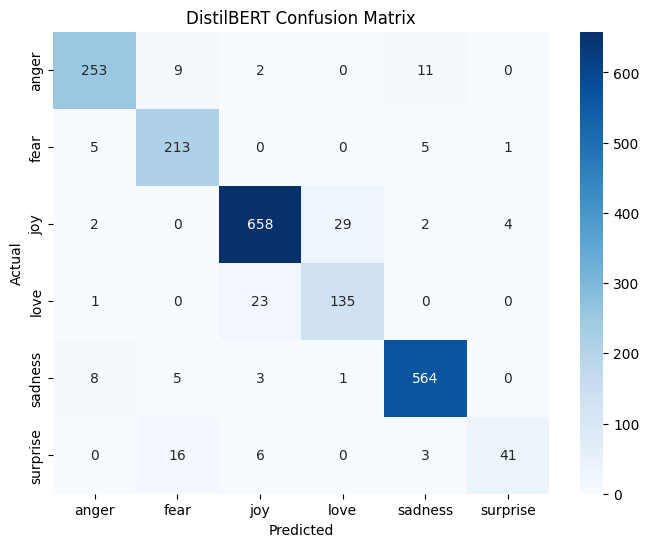

In [698]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("DistilBERT Confusion Matrix")

plt.show()

In [699]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.932
Precision : 0.9324509943180077
Recall : 0.932
F1 Score : 0.9312171562666013


In [700]:
distilbert_results = {
    "Model": "DistilBERT",
    "Loss": results["eval_loss"],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [701]:
# Save the Model

SAVE_PATH = "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/DistilBERT"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("DistilBERT Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT Model Saved Successfully


# RoBERTa

In [702]:
# Import Libraries

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

In [703]:
# Load Tokenizer

MODEL_NAME = "roberta-base"

tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

In [704]:
# Tokenize Dataset

train_encodings = tokenizer(
    train_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_df["Clean_Text_BERT"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [705]:
# Custom Dataset

class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [706]:
# Create Dataset

train_dataset = EmotionDataset(
    train_encodings,
    train_df["Label"].tolist()
)

val_dataset = EmotionDataset(
    val_encodings,
    val_df["Label"].tolist()
)

test_dataset = EmotionDataset(
    test_encodings,
    test_df["Label"].tolist()
)

In [707]:
# Verify Dataset

print(train_dataset[0])

{'input_ids': tensor([    0,   118, 46405,   619, 32386,     2,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [708]:
# Load RoBERTa Model

NUM_CLASSES = len(encoder.classes_)

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

print(model)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [709]:
# Data Collator

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [710]:
# Load Accuracy Metric

accuracy_metric = evaluate.load("accuracy")

In [711]:
# Compute Metrics

from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [712]:
# Training Arguments

training_args = TrainingArguments(

    output_dir="./roberta_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none"
)

In [713]:
# Create Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [714]:
# Train the Model

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.493505,0.212382,0.921000,0.924262,0.921000,0.921581
2,0.185380,0.165765,0.932500,0.933143,0.932500,0.931679
3,0.126260,0.156374,0.935500,0.936020,0.935500,0.935531


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.26838194783528646, metrics={'train_runtime': 997.4417, 'train_samples_per_second': 48.123, 'train_steps_per_second': 3.008, 'total_flos': 2170744164864000.0, 'train_loss': 0.26838194783528646, 'epoch': 3.0})

In [715]:
# Evaluate the Model

results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.126260,0.156374,3,0.935500,0.936020,0.935500,0.935531


{'eval_loss': 0.15637442469596863, 'eval_accuracy': 0.9355, 'eval_precision': 0.9360204854366345, 'eval_recall': 0.9355, 'eval_f1': 0.9355310799229722}


In [716]:
# Prepare training history

history = pd.DataFrame(trainer.state.log_history)

history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.493505,4.537941,1.334000e-05,1.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1000,0.212382,0.9210,0.924262,0.9210,0.921581,8.4987,235.331,14.708,NaN,NaN,NaN,NaN,NaN
2,0.185380,5.633143,6.673333e-06,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,2000,0.165765,0.9325,0.933143,0.9325,0.931679,8.5176,234.808,14.675,NaN,NaN,NaN,NaN,NaN
4,0.126260,1.182232,6.666667e-09,3.0,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,3000,0.156374,0.9355,0.936020,0.9355,0.935531,8.6099,232.292,14.518,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,997.4417,48.123,3.008,2.170744e+15,0.268382
7,NaN,NaN,NaN,3.0,3000,0.156374,0.9355,0.936020,0.9355,0.935531,8.2683,241.887,15.118,NaN,NaN,NaN,NaN,NaN


In [717]:
# Save Training Log

history.to_csv(
    "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/RoBERTa_Training_Log.csv",
    index=False
)

print("Training Log Saved Successfully")

Training Log Saved Successfully


In [718]:
# Prepare history

train_history = history[history["loss"].notna()].copy()

val_history = history[history["eval_loss"].notna()].copy()

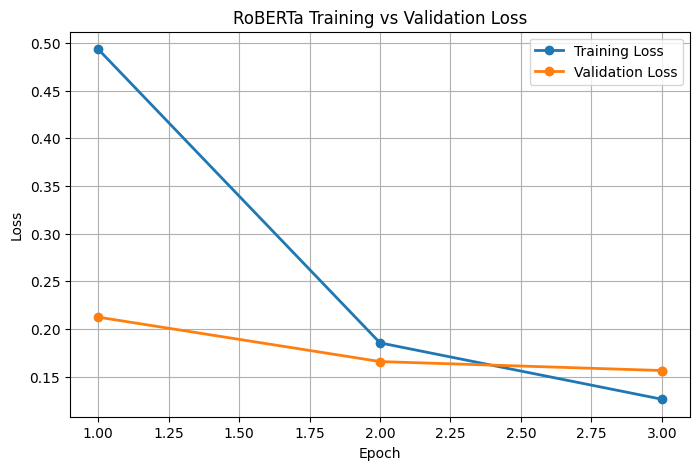

In [719]:
# Training vs Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    val_history["epoch"],
    val_history["eval_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

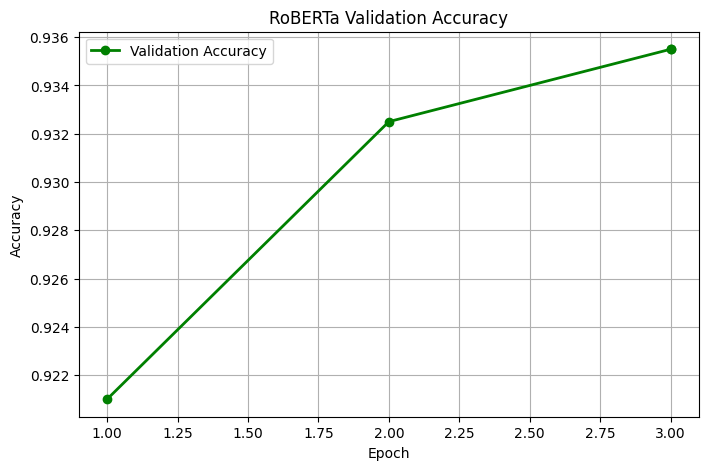

In [720]:
# Validation Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(
    val_history["epoch"],
    val_history["eval_accuracy"],
    marker="o",
    linewidth=2,
    color="green",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RoBERTa Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [721]:
# Overfitting Check

train_loss = train_history.iloc[-1]["loss"]

val_loss = val_history.iloc[-1]["eval_loss"]

print("Final Training Loss :", round(train_loss,4))
print("Final Validation Loss :", round(val_loss,4))

difference = abs(train_loss - val_loss)

print("Loss Difference :", round(difference,4))

if difference <= 0.10:
    print("Conclusion : Model is Well Generalized")

elif val_loss > train_loss:
    print("Conclusion : Slight Overfitting")

else:
    print("Conclusion : Slight Underfitting")

Final Training Loss : 0.1263
Final Validation Loss : 0.1564
Loss Difference : 0.0301
Conclusion : Model is Well Generalized


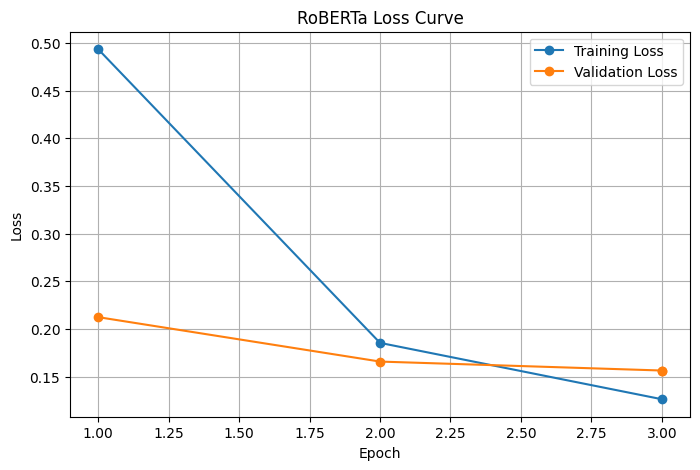

In [722]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_history["epoch"],
    val_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Loss Curve")

plt.legend()
plt.grid(True)


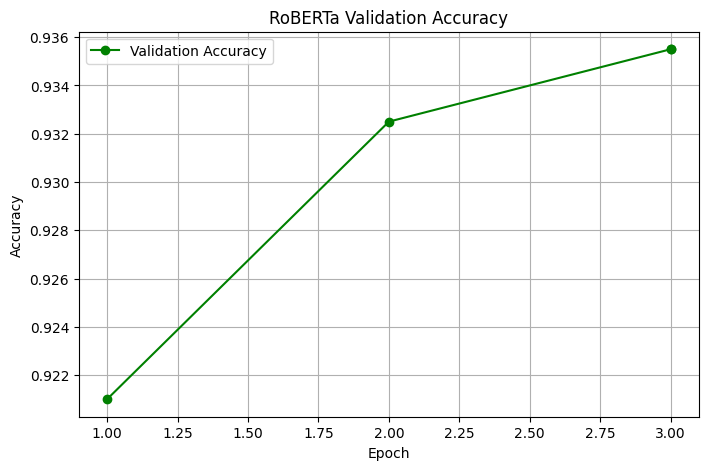

In [723]:
# Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(
    val_history["epoch"],
    val_history["eval_accuracy"],
    marker="o",
    color="green",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RoBERTa Validation Accuracy")

plt.legend()
plt.grid(True)


In [724]:
# Test Prediction

print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

       anger       0.94      0.92      0.93       275
        fear       0.88      0.95      0.91       224
         joy       0.95      0.95      0.95       695
        love       0.82      0.85      0.83       159
     sadness       0.96      0.97      0.97       581
    surprise       0.89      0.62      0.73        66

    accuracy                           0.93      2000
   macro avg       0.91      0.88      0.89      2000
weighted avg       0.93      0.93      0.93      2000



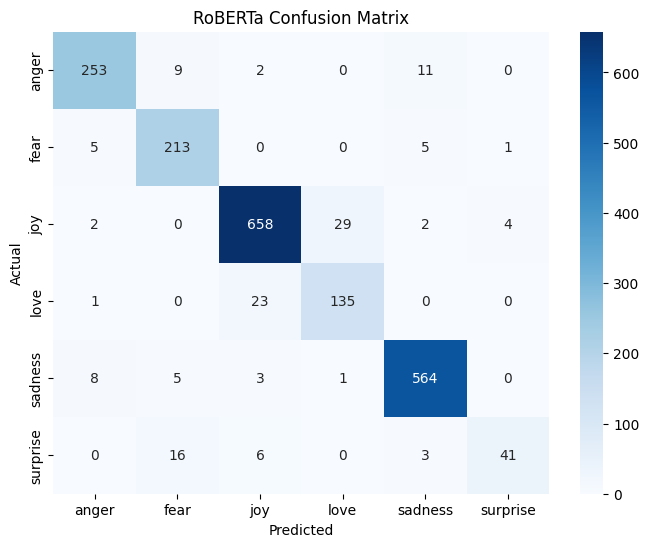

In [725]:
# Confusion Matrix

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RoBERTa Confusion Matrix")

plt.show()

In [726]:
# Performance Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.932
Precision : 0.9324509943180077
Recall : 0.932
F1 Score : 0.9312171562666013


In [727]:
roberta_results = {
    "Model": "RoBERTa",
    "Loss": results["eval_loss"],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [728]:
# Save RoBERTa Model

SAVE_PATH = "/content/drive/MyDrive/Emotion Detection from Text using Deep Learning and Transformer Models_dataset/Models/RoBERTa"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("RoBERTa Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa Model Saved Successfully


In [730]:
import pandas as pd

comparison_df = pd.DataFrame([

    rnn_results,
    lstm_results,
    gru_results,
    birnn_results,
    bilstm_results,
    bigru_results,
    stacked_rnn_results,
    stacked_lstm_results,
    stacked_gru_results,
    tuned_lstm_results,
    bert_results,
    distilbert_results,
    roberta_results

])

comparison_df = comparison_df.round(4)

comparison_df

,Model,Loss,Accuracy,Precision,Recall,F1 Score
0,Simple RNN,0.2080,0.9320,0.9325,0.9320,0.9312
1,LSTM,0.2582,0.9060,0.9088,0.9060,0.9069
2,GRU,0.2039,0.9125,0.9176,0.9125,0.9140
3,Bi-RNN,0.3844,0.8625,0.8621,0.8625,0.8620
4,Bi-LSTM,0.2943,0.9010,0.9035,0.9010,0.9018
5,Bi-GRU,0.2201,0.9105,0.9098,0.9105,0.9094
6,Stacked RNN,0.4959,0.8465,0.8597,0.8465,0.8493
7,Stacked LSTM,0.2279,0.9120,0.9163,0.9120,0.9135
8,Stacked GRU,0.2219,0.9160,0.9197,0.9160,0.9171
9,Tuned LSTM,0.2080,0.9190,0.9198,0.9190,0.9163


Final Conclusion:

Thirteen deep learning and transformer-based models were implemented and evaluated for multi-class emotion detection from text. Performance was assessed using loss, accuracy, precision, recall, and F1-score. Transformer models consistently demonstrated strong contextual language understanding, with DistilBERT and RoBERTa achieving the highest accuracy of 93.20%. Among the recurrent neural network architectures, the Simple RNN also achieved an accuracy of 93.20%, while the Tuned LSTM and Stacked GRU showed competitive performance. Considering both predictive performance and computational efficiency, DistilBERT emerged as the most suitable model for this project, making it an effective choice for emotion classification tasks in real-world NLP applications.